In [58]:
import kagglehub
import polars as pl
from matplotlib import pyplot as plt
import csv
import cv2
from torch.nn import functional as F
import torch
import glob
import cv2
from torchvision.transforms import v2
from torchvision.io import decode_image
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import yaml
import re

In [46]:
def load_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    
    return data

In [47]:
data = load_yaml("../config/dataset.yaml")

'C:/Users/siran/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1'

In [51]:
DATA_DIR = data["DATA_DIR"]
IMAGES_DIR = rf"{data['DATA_DIR']}/{data['PATHS']["IMAGES"]}"
CAPTIONS_CSV = rf"{data['DATA_DIR']}/{data['PATHS']["CAPTIONS"]}"
WORD_DICT_CSV = rf"{data['DATA_DIR']}/{data['PATHS']["WORD_DICT"]}"

TEST_SIZE = 0.2
BATCH_SIZE = 64

In [52]:
DATA_DIR, IMAGES_DIR, CAPTIONS_CSV, WORD_DICT_CSV

('C:/Users/siran/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1',
 'C:/Users/siran/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images',
 'C:/Users/siran/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/captions.csv',
 'C:/Users/siran/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/word_dict.csv')

In [53]:
df = pl.read_csv(CAPTIONS_CSV)

In [54]:
df.describe()

statistic,image,caption
str,str,str
"""count""","""40455""","""40455"""
"""null_count""","""0""","""0"""
"""mean""",null,null
"""std""",null,null
"""min""","""1000268201_693b08cb0e.jpg""","""<start> 2 People with white ha…"
"""25%""",null,null
"""50%""",null,null
"""75%""",null,null
"""max""","""997722733_0cb5439472.jpg""","""<start> young girl kneels on a…"


### 学習とテストデータに分ける

In [55]:
train_df = df[:int(len(df) * (1 - TEST_SIZE))]
test_df = df[int((len(df) * (1 - TEST_SIZE))):]

In [14]:
len(train_df), len(test_df)

(32364, 8091)

In [15]:
train_df.tail(3), test_df.head(3)

(shape: (3, 2)
 ┌───────────────────────────┬─────────────────────────────────┐
 │ image                     ┆ caption                         │
 │ ---                       ┆ ---                             │
 │ str                       ┆ str                             │
 ╞═══════════════════════════╪═════════════════════════════════╡
 │ 3601569729_bf4bf82768.jpg ┆ <start> A horse race . <end> <… │
 │ 3601569729_bf4bf82768.jpg ┆ <start> Jockeys on horses duri… │
 │ 3601569729_bf4bf82768.jpg ┆ <start> The horses race on the… │
 └───────────────────────────┴─────────────────────────────────┘,
 shape: (3, 2)
 ┌───────────────────────────┬─────────────────────────────────┐
 │ image                     ┆ caption                         │
 │ ---                       ┆ ---                             │
 │ str                       ┆ str                             │
 ╞═══════════════════════════╪═════════════════════════════════╡
 │ 3601569729_bf4bf82768.jpg ┆ <start> There are riders and

In [19]:
class CustomDataset(Dataset):
    def __init__(self, train_df, transform=None):
        self.transform = transform
        self.df = train_df
    
    def __getitem__(self, idx):

        image_path, caption = self.df.item(idx, "image"), self.df.item(idx, "caption")
        image = self.__read_img(image_path)

        if self.transform:
            image = self.transform(image)
        
        return image, caption

    def __len__(self):
        return len(self.df)

    def __read_img(self, image_path):
        image = cv2.imread(rf"{IMAGES_DIR}\{image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = torch.from_numpy(image).permute(2, 0, 1).float()

        return image

In [17]:
transform = v2.Compose([
    v2.Resize((224, 224)),
    # v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [20]:
train_dataset = CustomDataset(train_df, transform=transform)
test_dataset = CustomDataset(test_df, transform=transform)

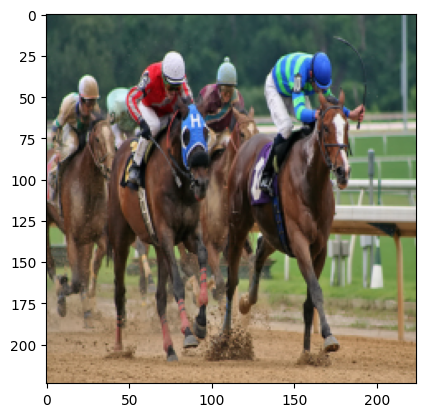

In [23]:
plt.imshow(test_dataset[0][0].permute(1, 2, 0).byte())

In [28]:
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [36]:
train_sample = next(iter(train_data_loader))
train_sample[0].shape, len(train_sample[1])

(torch.Size([64, 3, 224, 224]), 64)

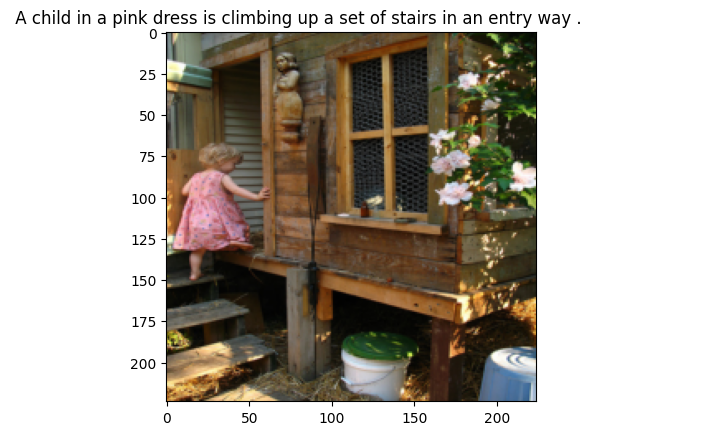

In [59]:
plt.imshow(train_sample[0][0].permute(1, 2, 0).byte())
plt.title(re.sub(r'<(?:start|end|pad)>', '', train_sample[1][0]))
plt.show()

In [63]:
a, b = train_sample

In [71]:
for image, caption in train_data_loader:
    print(image, caption)
    break

tensor([[[[ 81.5030, 111.2995, 116.1153,  ...,   4.4173,   5.5659,   5.6888],
          [ 78.9109, 113.0165, 118.9670,  ...,   7.8355,   6.8419,  12.2938],
          [ 76.7290, 116.6420, 120.3948,  ...,   7.9718,   7.3403,  10.2015],
          ...,
          [185.5755, 149.7598, 170.7673,  ..., 211.6241, 164.9813, 164.7488],
          [176.6574, 177.5888, 220.2637,  ..., 209.3573, 167.5277, 167.8587],
          [207.3142, 208.7147, 186.6543,  ..., 205.0892, 166.8030, 168.8149]],

         [[ 87.7608, 127.7647, 133.8673,  ...,   3.2286,   6.0906,   8.2140],
          [ 84.1368, 129.1545, 138.2088,  ...,   8.9206,   9.6277,  20.7478],
          [ 79.3139, 132.0911, 141.3049,  ...,   9.5327,  12.8977,  22.3993],
          ...,
          [108.3441,  79.8883, 121.7180,  ..., 220.4553, 184.3633, 184.1786],
          [ 96.1618, 128.6248, 168.7934,  ..., 218.1183, 183.7523, 184.0135],
          [125.9477, 148.1448, 122.1378,  ..., 213.6293, 183.7200, 183.9076]],

         [[ 96.7174, 124.7716,